# 01 - EDA: Raw Sales Data

Shared exploration of `sales.csv` for the team. Each model notebook
(`02_LSTM.ipynb`, `03_RNN.ipynb`, etc.) builds on what is documented here.

In [1]:
import sys, os
# Make project root importable when this notebook is run from notebooks/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))  # so sales.csv resolves

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing

df = preprocessing.load_raw_sales("sales.csv")
print(df.shape)
df.head()

(7432685, 6)


,date,item_id,quantity,price_base,sum_total,store_id
0,2023-08-04,293375605257,1.000,47.86,47.86,1
1,2023-08-04,a66fdf2c0ae7,3.000,49.60,148.80,1
2,2023-08-04,daa46ef49b7a,0.822,379.00,311.54,1
3,2023-08-04,a3b49c1bf758,1.000,129.00,129.00,1
4,2023-08-04,ab611c5cef62,7.000,79.90,559.30,1


## Shape and date range

In [2]:
print(f"rows: {len(df):,}")
print(f"date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"days covered: {df['date'].nunique()}")
print(f"unique items: {df['item_id'].nunique():,}")
print(f"unique stores: {df['store_id'].nunique()}")
print()
print("nulls per column:")
print(df.isna().sum())

rows: 7,432,685
date range: 2022-08-28 -> 2024-09-26


days covered: 761


unique items: 28,182
unique stores: 4

nulls per column:


date          0
item_id       0
quantity      0
price_base    0
sum_total     0
store_id      0
dtype: int64


## Quantity distribution and returns

In [3]:
print(df["quantity"].describe(percentiles=[.5, .75, .9, .99]))
n_returns = (df["quantity"] < 0).sum()
print()
print(f"negative-quantity rows (returns): {n_returns:,} ({100*n_returns/len(df):.2f}%)")

count    7.432685e+06
mean     5.642398e+00
std      2.740466e+01
min     -5.000000e+02
50%      2.000000e+00
75%      4.672000e+00
90%      1.000000e+01
99%      5.700000e+01
max      4.952000e+03
Name: quantity, dtype: float64

negative-quantity rows (returns): 1,160 (0.02%)


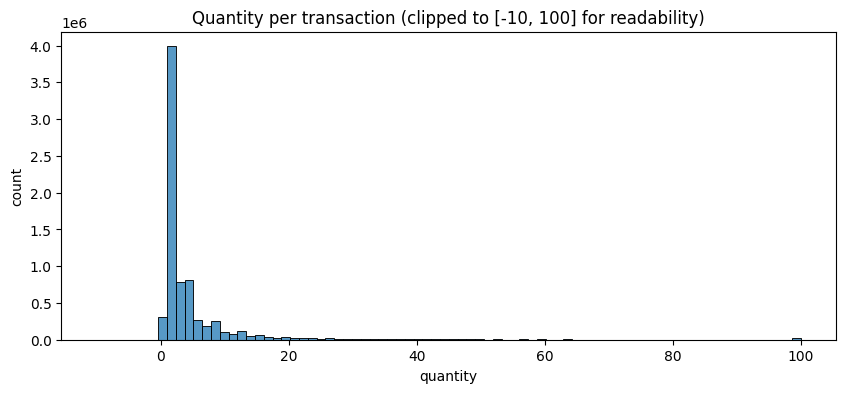

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["quantity"].clip(-10, 100), bins=80, ax=ax)
ax.set_title("Quantity per transaction (clipped to [-10, 100] for readability)")
ax.set_xlabel("quantity"); ax.set_ylabel("count")
plt.show()

## Per-product activity

In [5]:
daily = preprocessing.aggregate_daily(df)
per_item = (daily.groupby("item_id")
                  .agg(days_with_sales=("date", "nunique"),
                       total_qty=("quantity", "sum"))
                  .sort_values("total_qty", ascending=False))
print("days_with_sales distribution:")
print(per_item["days_with_sales"].describe(percentiles=[.5, .9, .99]).round(1))
print()
print("Products with full 761-day history:",
      (per_item["days_with_sales"] >= 761).sum())
per_item.head(10)

days_with_sales distribution:
count    28182.0
mean       175.5
std        216.0
min          1.0
50%         72.0
90%        554.0
99%        759.0
max        761.0
Name: days_with_sales, dtype: float64

Products with full 761-day history: 187


,days_with_sales,total_qty
item_id,,
b0d24502fb66,761,2022732.000
9a7e315f3f42,761,563403.013
63161948a95a,761,434289.000
e5b2b6f57ea7,761,358707.000
0973df3ff57f,761,344912.918
b5aac3497e3f,684,230549.000
6d284b4e9982,761,205106.000
5b8e114fdf6f,564,174563.044
9b4865c6faf1,759,170768.000


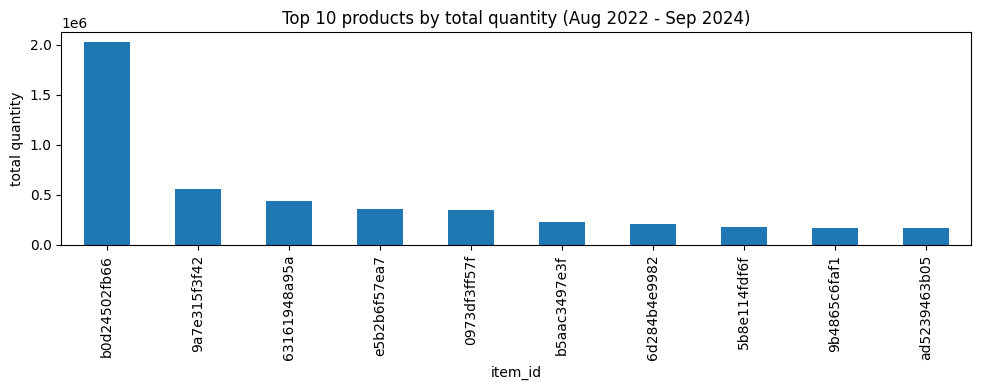

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
per_item.head(10)["total_qty"].plot(kind="bar", ax=ax)
ax.set_title("Top 10 products by total quantity (Aug 2022 - Sep 2024)")
ax.set_ylabel("total quantity"); ax.set_xlabel("item_id")
plt.tight_layout(); plt.show()

## Aggregate daily volume

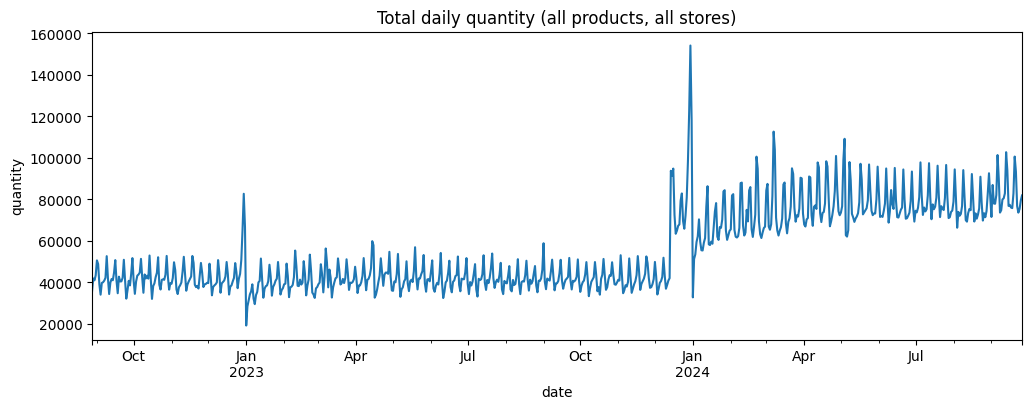

In [7]:
total_daily = daily.groupby("date")["quantity"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
total_daily.plot(ax=ax)
ax.set_title("Total daily quantity (all products, all stores)")
ax.set_ylabel("quantity"); ax.set_xlabel("date")
plt.show()

## Weekly seasonality

C:\Users\raymo\AppData\Local\Temp\ipykernel_27616\3853096261.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])


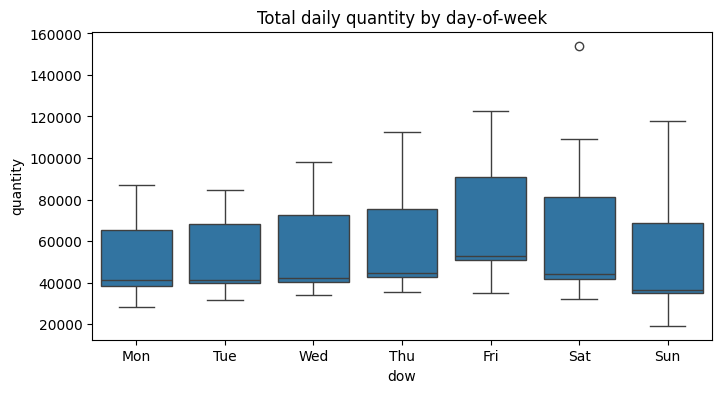

In [8]:
total_daily_df = total_daily.reset_index()
total_daily_df["dow"] = total_daily_df["date"].dt.dayofweek
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=total_daily_df, x="dow", y="quantity", ax=ax)
ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_title("Total daily quantity by day-of-week")
plt.show()

## Key findings used downstream by 02_LSTM.ipynb

- 761 days of data, ~28k unique items, 4 stores.
- Most products are sparse (median ~72 days of sales) - only the heavy-volume head
  has the full history needed for a 30-day LSTM forecast.
- Negative quantities (returns) are present and are netted into daily totals.
- Clear weekly seasonality at the aggregate level -> calendar features will help.